<a href="https://colab.research.google.com/github/FerasAljayyousi/ML-DL-Projects/blob/main/House_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#data gathering
#import data from drive

file_path = '/content/HousePrices_HalfMil.csv'

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df = pd.read_csv(file_path)
df

,Area,Garage,FirePlace,Baths,White Marble,Black Marble,Indian Marble,Floors,City,Solar,Electric,Fiber,Glass Doors,Swiming Pool,Garden,Prices
0,164,2,0,2,0,1,0,0,3.0,1.0,1.0,1.0,1.0,0.0,0.0,43800.0
1,84,2,0,4,0,0,1,1,2.0,0.0,0.0,0.0,1.0,1.0,1.0,37550.0
2,190,2,4,4,1,0,0,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,49500.0
3,75,2,4,4,0,0,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,50075.0
4,148,1,4,2,1,0,0,1,2.0,1.0,0.0,0.0,1.0,1.0,1.0,52400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380633,30,3,4,1,0,0,1,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,14250.0
380634,149,2,1,1,0,1,0,0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,34675.0
380635,123,1,1,1,0,1,0,0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,19575.0
380636,184,3,2,3,1,0,0,0,3.0,1.0,0.0,1.0,0.0,1.0,0.0,51850.0


In [ ]:
df['Area'].value_counts()

,count
Area,
61,1639
63,1622
247,1616
136,1613
176,1605
...,...
84,1441
156,1438
237,1434


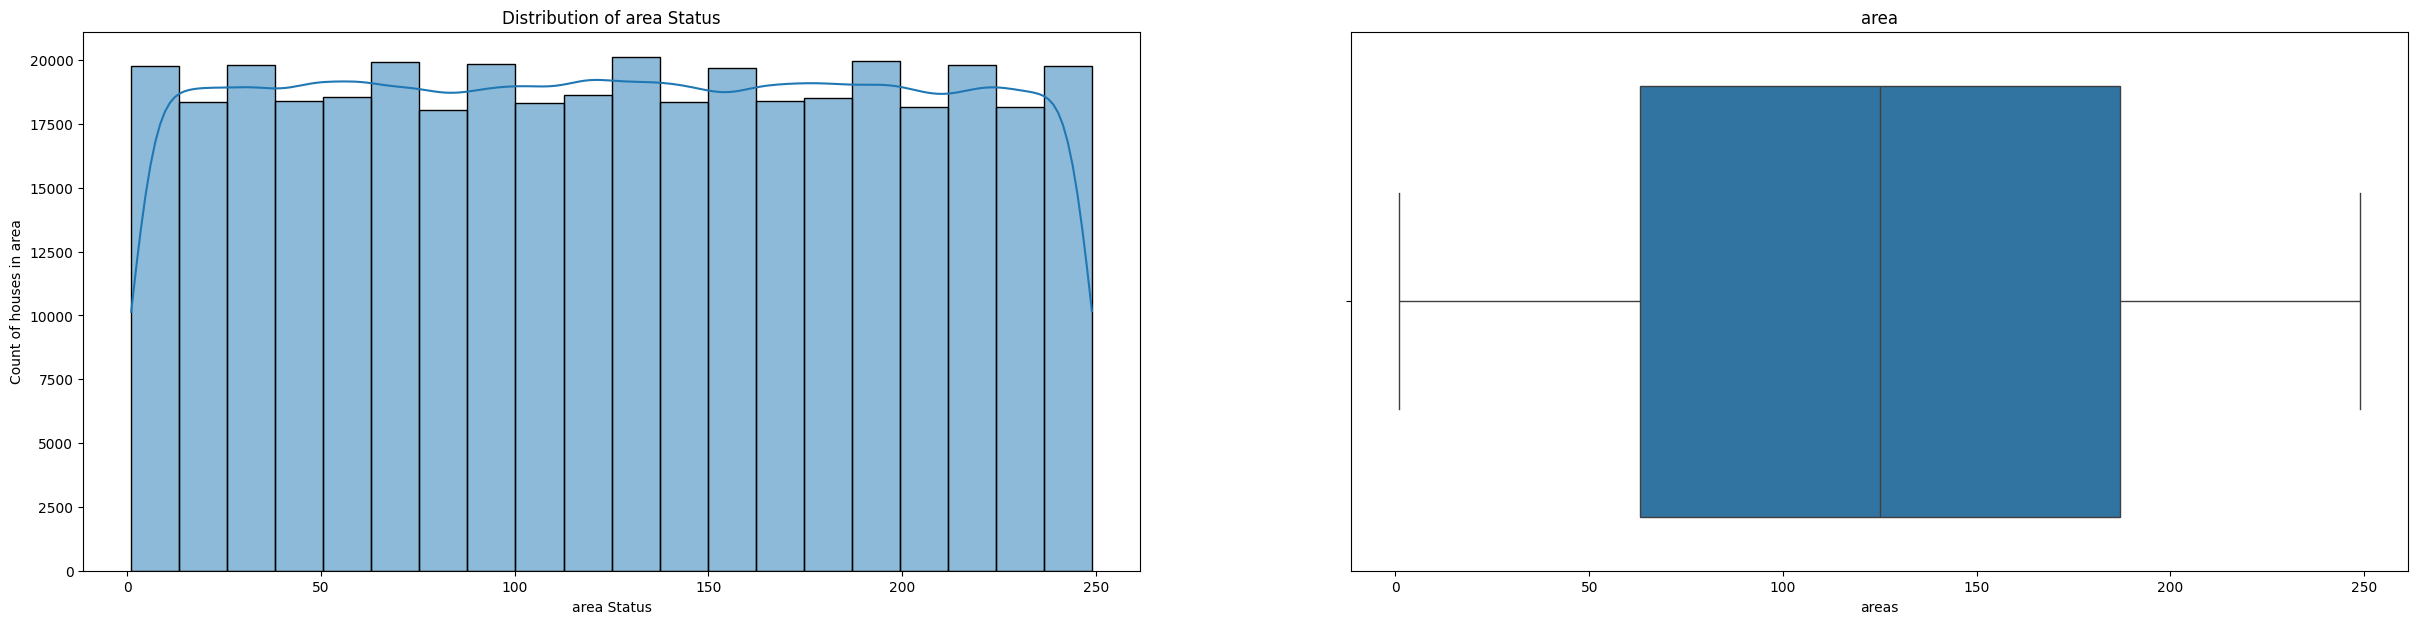

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(30, 7))
# area_count = df['Area'].value_counts()

sns.histplot(df['Area'], bins=20, kde=True, ax = ax[0])
ax[0].set_title('Distribution of area Status')
ax[0].set_xlabel('area Status')
ax[0].set_ylabel('Count of houses in area')




sns.boxplot(x=df['Area'], orient='H', ax = ax[1])
ax[1].set_title('area')
ax[1].set_xlabel('areas')
plt.tight_layout
plt.show()

In [ ]:
Garage_count = df['Garage'].value_counts()
Garage_count

,count
Garage,
3,127359
1,126711
2,126568


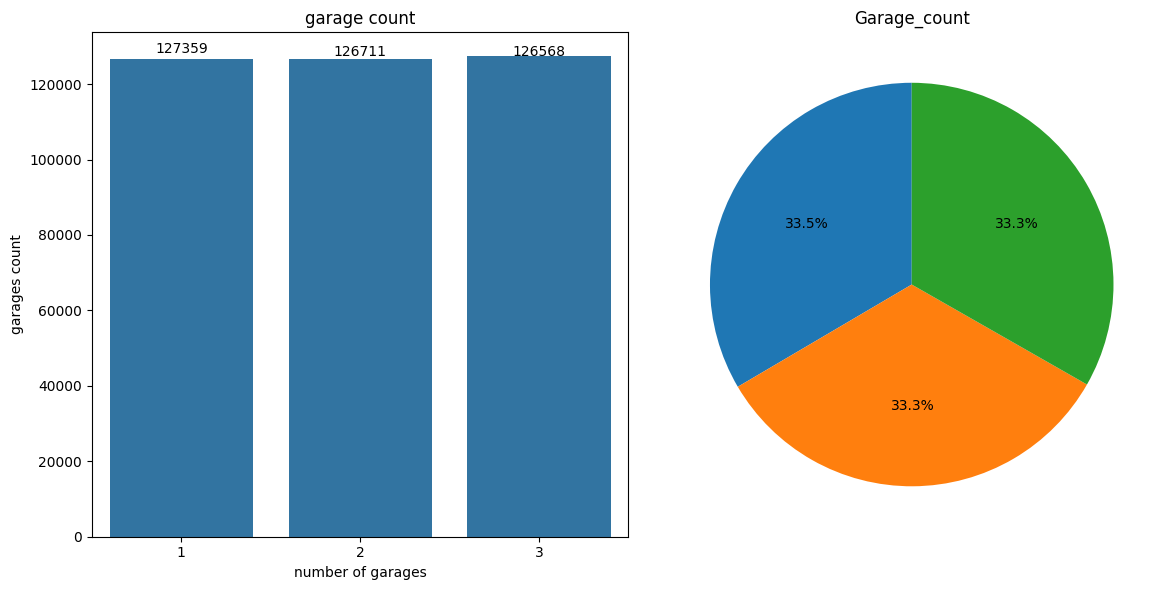

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Garage_count.index, y=Garage_count.values, ax=ax[0])
ax[0].set_xlabel('number of garages')
ax[0].set_ylabel('garages count')
ax[0].set_title('garage count')

for i, count in enumerate(Garage_count):
  ax[0].text(i, count,str(count), ha='center', va='bottom')

ax[1].pie(Garage_count, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Garage_count')
plt.tight_layout()
plt.show()

In [ ]:
FirePlace_count = df['FirePlace'].value_counts()
FirePlace_count

,count
FirePlace,
4,76376
3,76345
1,76163
2,76041
0,75713


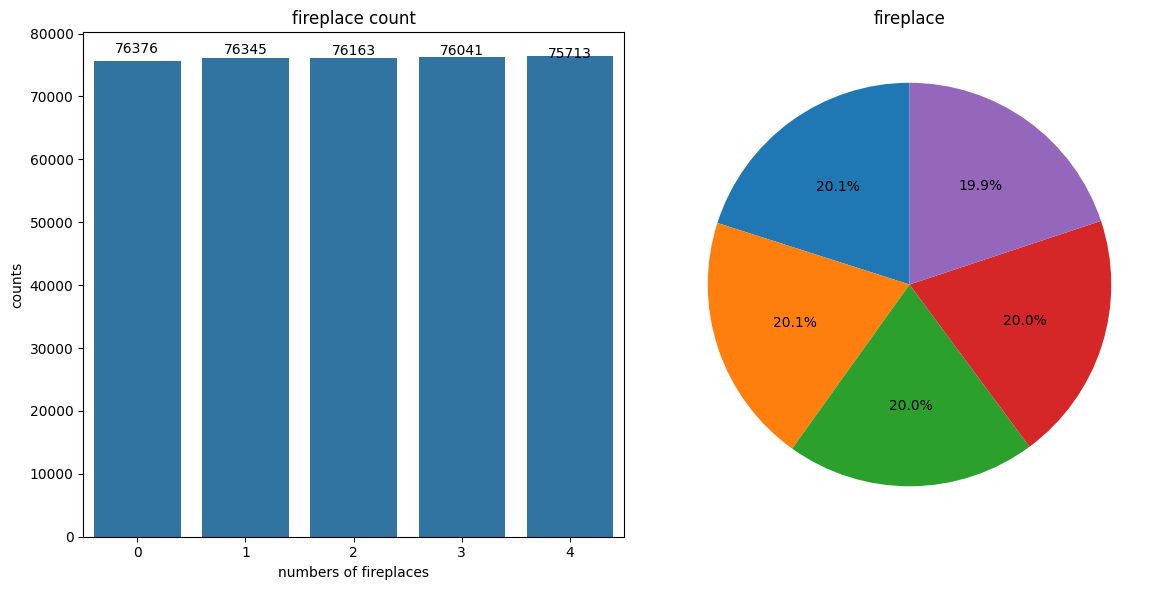

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=FirePlace_count.index, y=FirePlace_count.values, ax=ax[0])
ax[0].set_xlabel('numbers of fireplaces')
ax[0].set_ylabel('counts')
ax[0].set_title('fireplace count')

for i,count in enumerate(FirePlace_count):
  ax[0].text(i, count, str(count), ha='center', va='bottom')

ax[1].pie(FirePlace_count, autopct='%1.1f%%', startangle=90)
ax[1].set_title('fireplace')
plt.tight_layout()
plt.show()

In [ ]:
xx = df['Baths'].value_counts()
xx

,count
Baths,
1,76376
3,76374
4,76076
5,75965
2,75847


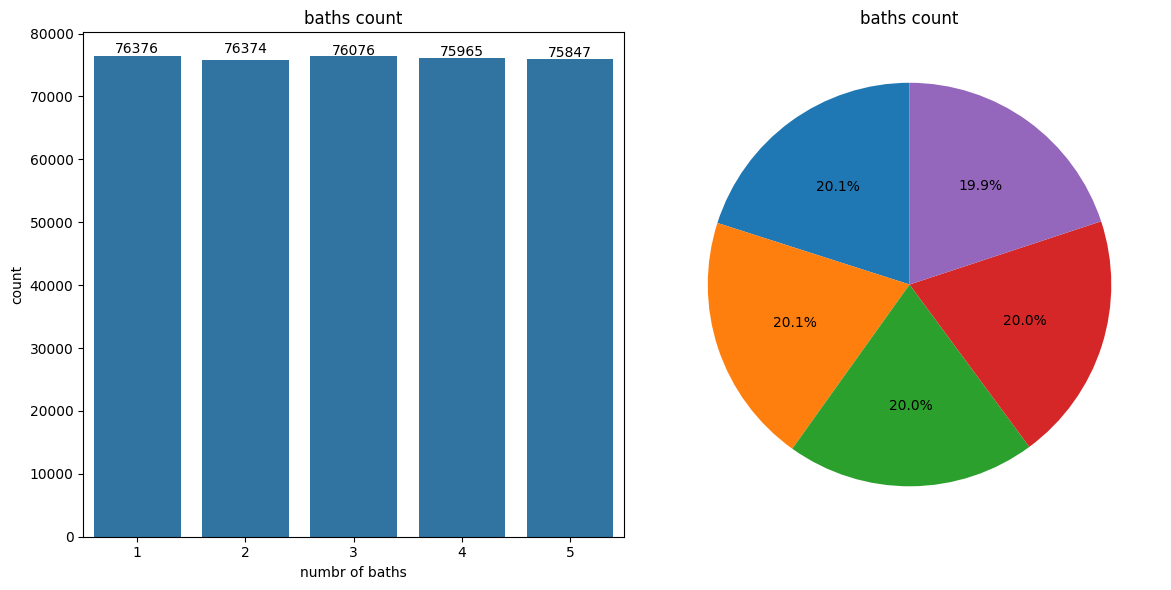

In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(30, 7))
# #histgram
# sns.histplot(df['Baths'], bins=20, kde=True, ax=ax[0])
# ax[0].set_title('baths count')
# ax[0].set_xlabel('numbr of baths')
# ax[0].set_ylabel('count')
# ###############################################
# #boxplot
# sns.boxplot(x=df['Baths'], orient='H', ax=ax[1])
# ax[1].set_title('baths count')
# ax[1].set_xlabel('numbr of baths')
# plt.tight_layout()
# plt.show()
baths_c = df['Baths'].value_counts()

fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x= baths_c.index,y=baths_c.values, ax=ax[0])
ax[0].set_title('baths count')
ax[0].set_xlabel('numbr of baths')
ax[0].set_ylabel('count')
###############################################
for i, count in enumerate(baths_c):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
ax[1].pie(baths_c , autopct='%1.1f%%', startangle=90 )
ax[1].set_title('baths count')
plt.tight_layout()
plt.show()

In [ ]:
White_Marble_count = df['White Marble'].value_counts()
White_Marble_count

,count
White Marble,
0,253967
1,126671


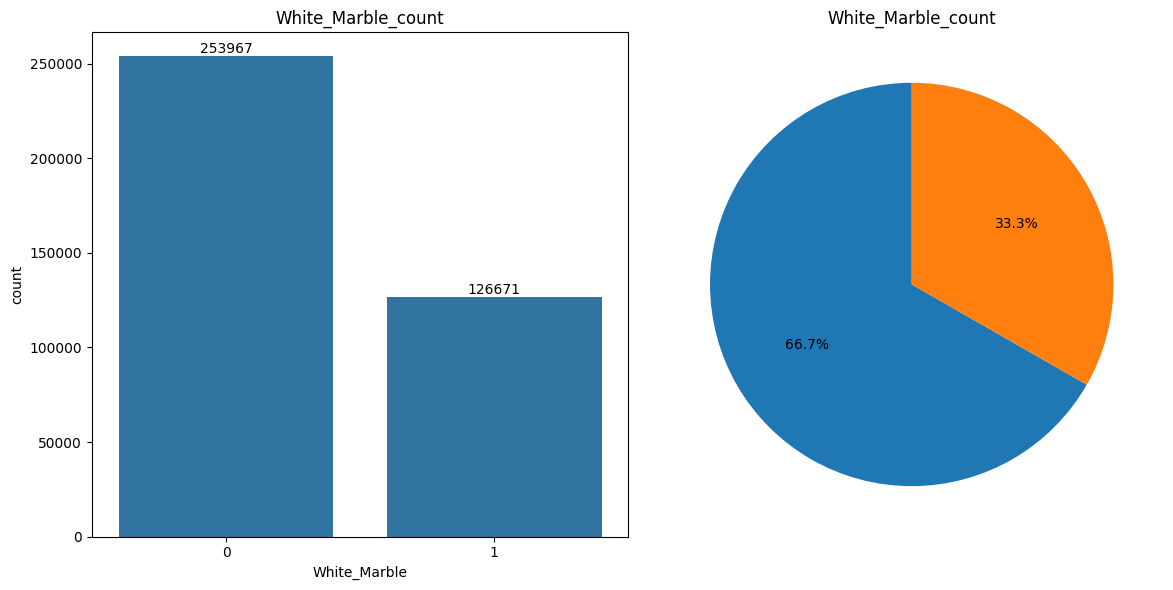

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
sns.barplot(x=White_Marble_count.index, y=White_Marble_count.values, ax=ax[0])
ax[0].set_title('White_Marble_count')
ax[0].set_xlabel('White_Marble')
ax[0].set_ylabel('count')

for i,count in enumerate(White_Marble_count):
  ax[0].text(i, count, str(count), ha='center', va='bottom')

ax[1].pie(White_Marble_count , autopct='%1.1f%%', startangle=90 )
ax[1].set_title('White_Marble_count')
plt.tight_layout()
plt.show()

In [ ]:
Black_Marble_count = df['Black Marble'].value_counts()
Black_Marble_count

,count
Black Marble,
0,253972
1,126666


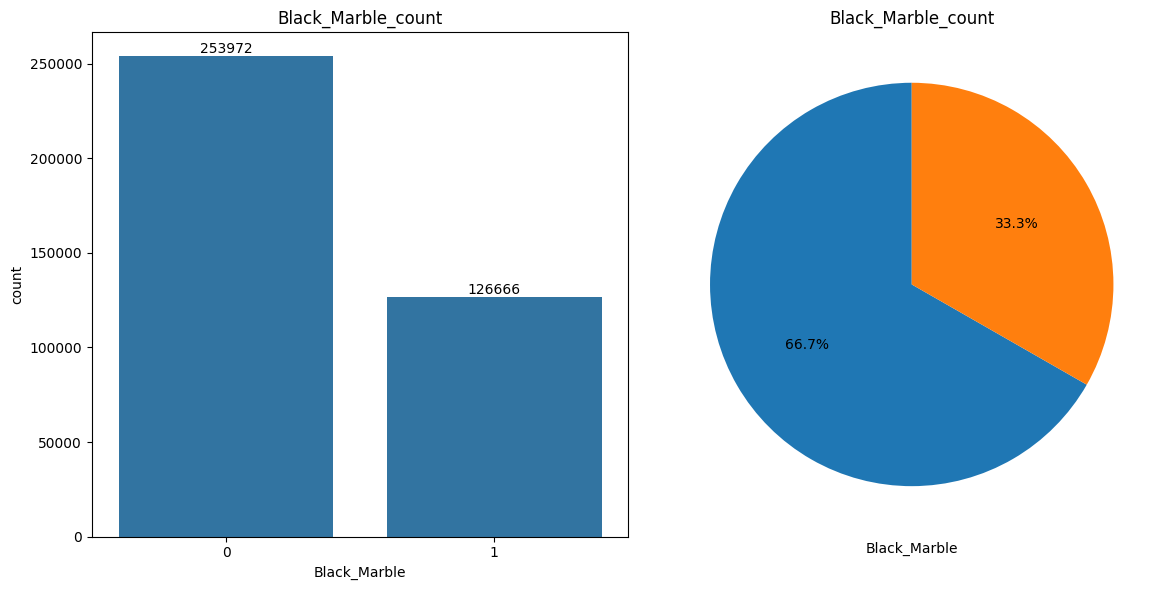

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Black_Marble_count.index, y=Black_Marble_count.values, ax=ax[0])
ax[0].set_title('Black_Marble_count')
ax[0].set_xlabel('Black_Marble')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Black_Marble_count):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Black_Marble_count, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Black_Marble_count')
ax[1].set_xlabel('Black_Marble')

plt.tight_layout()
plt.show()

In [ ]:
Indian_Marble_inf0 = df['Indian Marble'].value_counts()

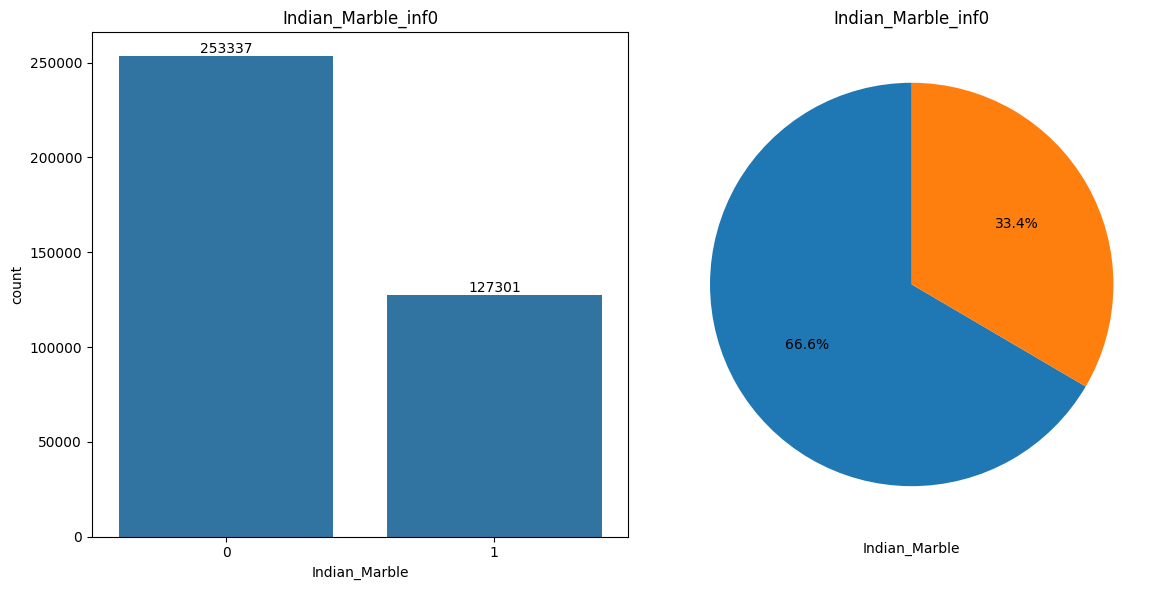

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Indian_Marble_inf0.index, y=Indian_Marble_inf0.values, ax=ax[0])
ax[0].set_title('Indian_Marble_inf0')
ax[0].set_xlabel('Indian_Marble')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Indian_Marble_inf0):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Indian_Marble_inf0, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Indian_Marble_inf0')
ax[1].set_xlabel('Indian_Marble')

plt.tight_layout()
plt.show()

In [ ]:
Floors_count = df['Floors'].value_counts()
Floors_count

,count
Floors,
0,190521
1,190117


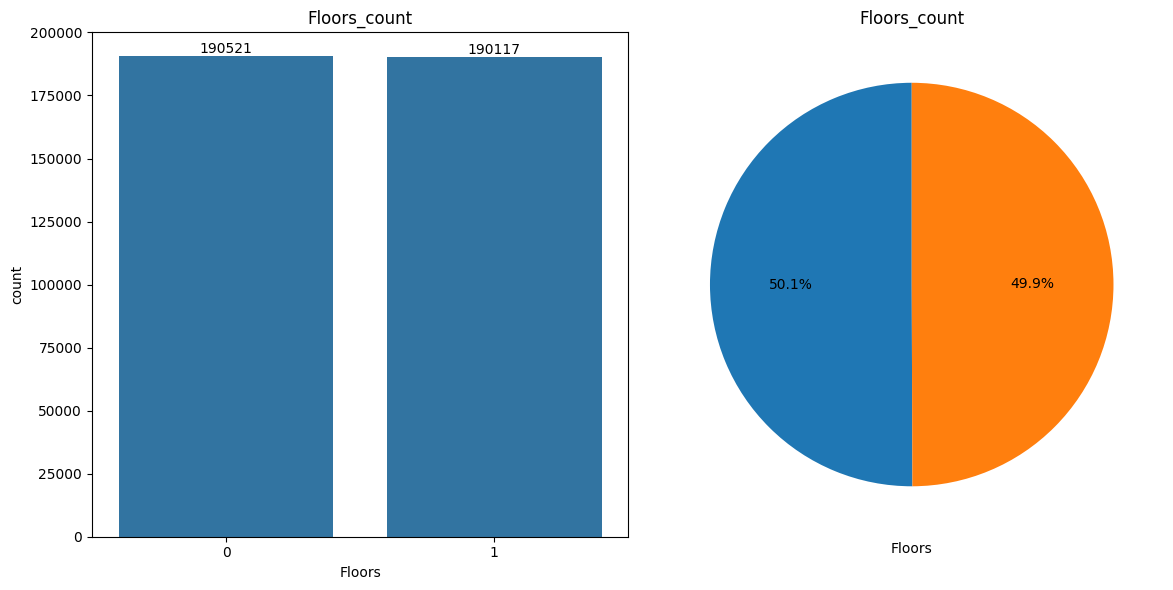

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Floors_count.index, y=Floors_count.values, ax=ax[0])
ax[0].set_title('Floors_count')
ax[0].set_xlabel('Floors')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Floors_count):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Floors_count, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Floors_count')
ax[1].set_xlabel('Floors')

plt.tight_layout()
plt.show()

In [ ]:
City_inf0 = df['City'].value_counts()
City_inf0

,count
City,
2.0,126974
3.0,126969
1.0,126694


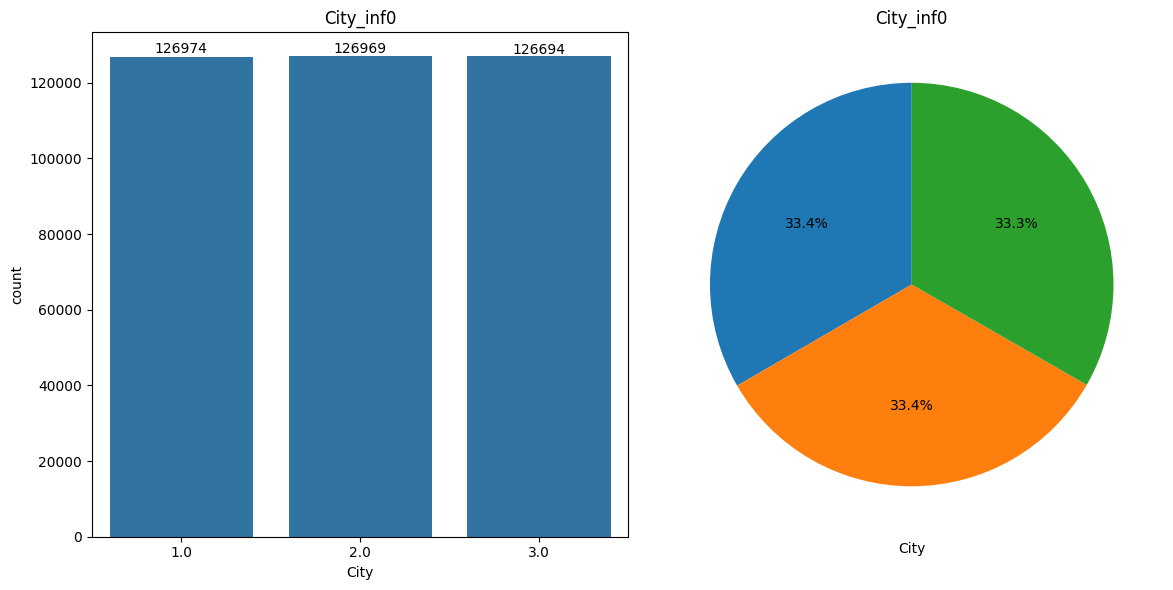

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=City_inf0.index, y=City_inf0.values, ax=ax[0])
ax[0].set_title('City_inf0')
ax[0].set_xlabel('City')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(City_inf0):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(City_inf0, autopct='%1.1f%%', startangle=90)
ax[1].set_title('City_inf0')
ax[1].set_xlabel('City')

plt.tight_layout()
plt.show()

In [ ]:
Solar_info = df['Solar'].value_counts()
Solar_info

,count
Solar,
0.0,190854
1.0,189783


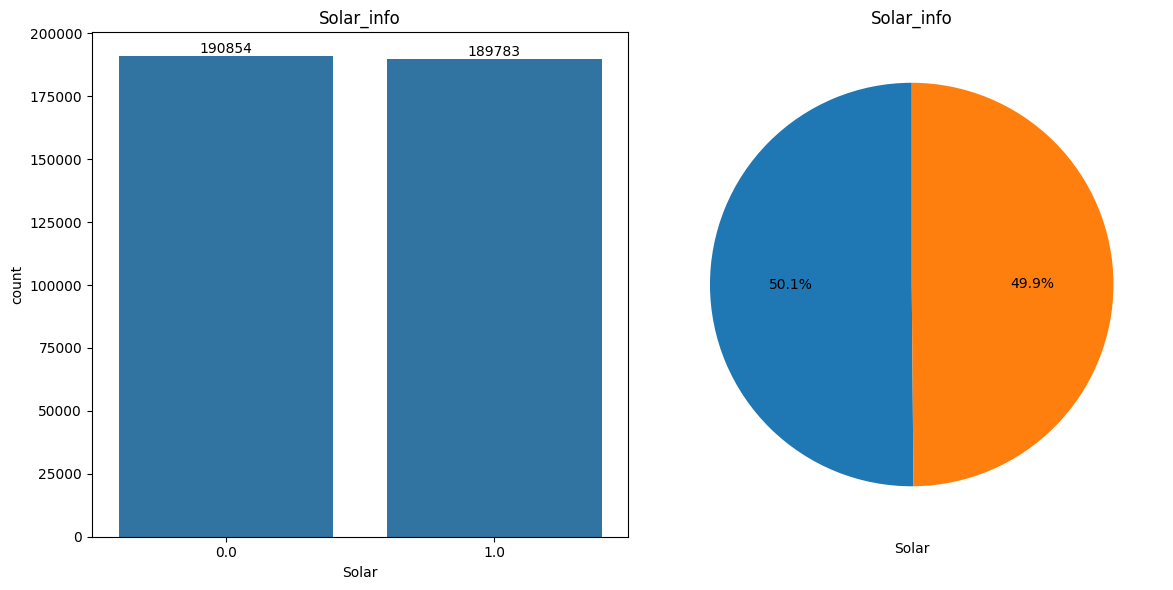

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Solar_info.index, y=Solar_info.values, ax=ax[0])
ax[0].set_title('Solar_info')
ax[0].set_xlabel('Solar')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Solar_info):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Solar_info, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Solar_info')
ax[1].set_xlabel('Solar')

plt.tight_layout()
plt.show()

In [ ]:
Electric_info = df['Electric'].value_counts()
Electric_info

,count
Electric,
1.0,190753
0.0,189884


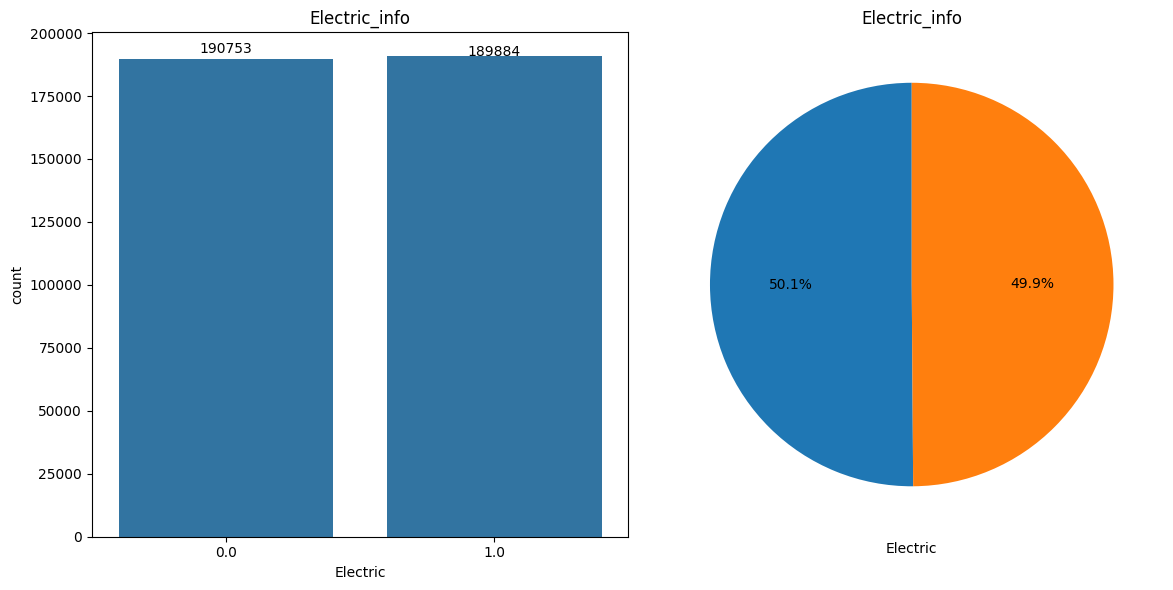

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Electric_info.index, y=Electric_info.values, ax=ax[0])
ax[0].set_title('Electric_info')
ax[0].set_xlabel('Electric')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Electric_info):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Electric_info, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Electric_info')
ax[1].set_xlabel('Electric')

plt.tight_layout()
plt.show()

In [ ]:
Fiber_inf0 = df['Fiber'].value_counts()
Fiber_inf0

,count
Fiber,
1.0,190679
0.0,189958


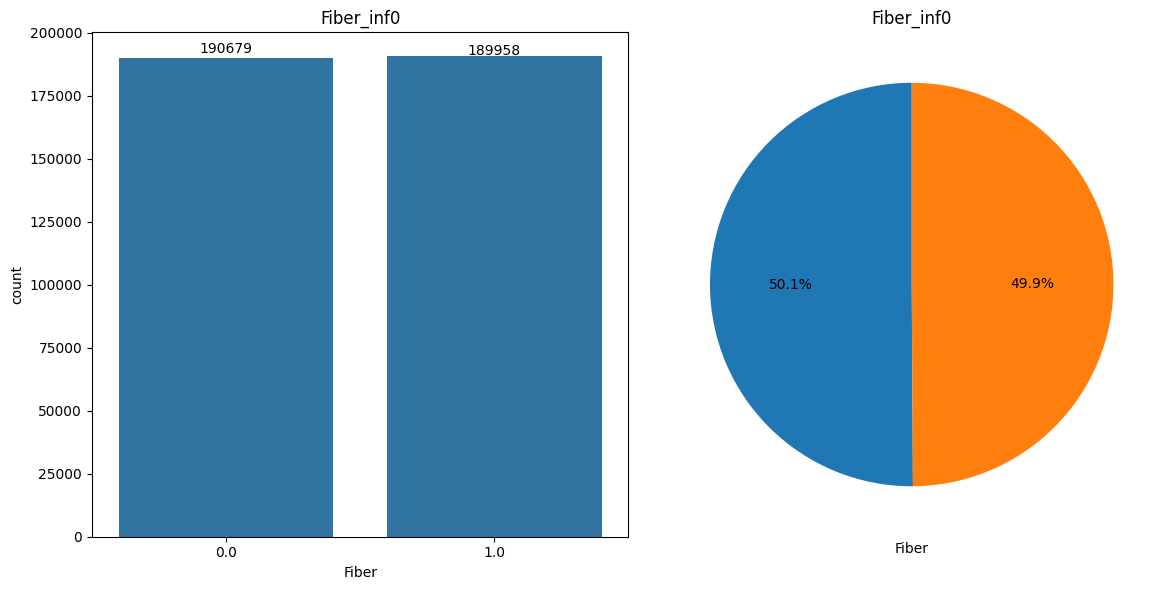

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Fiber_inf0.index, y=Fiber_inf0.values, ax=ax[0])
ax[0].set_title('Fiber_inf0')
ax[0].set_xlabel('Fiber')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Fiber_inf0):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Fiber_inf0, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Fiber_inf0')
ax[1].set_xlabel('Fiber')

plt.tight_layout()
plt.show()

In [ ]:
Glass_Doors_inf0 = df['Glass Doors'].value_counts()
Glass_Doors_inf0

,count
Glass Doors,
1.0,190479
0.0,190158


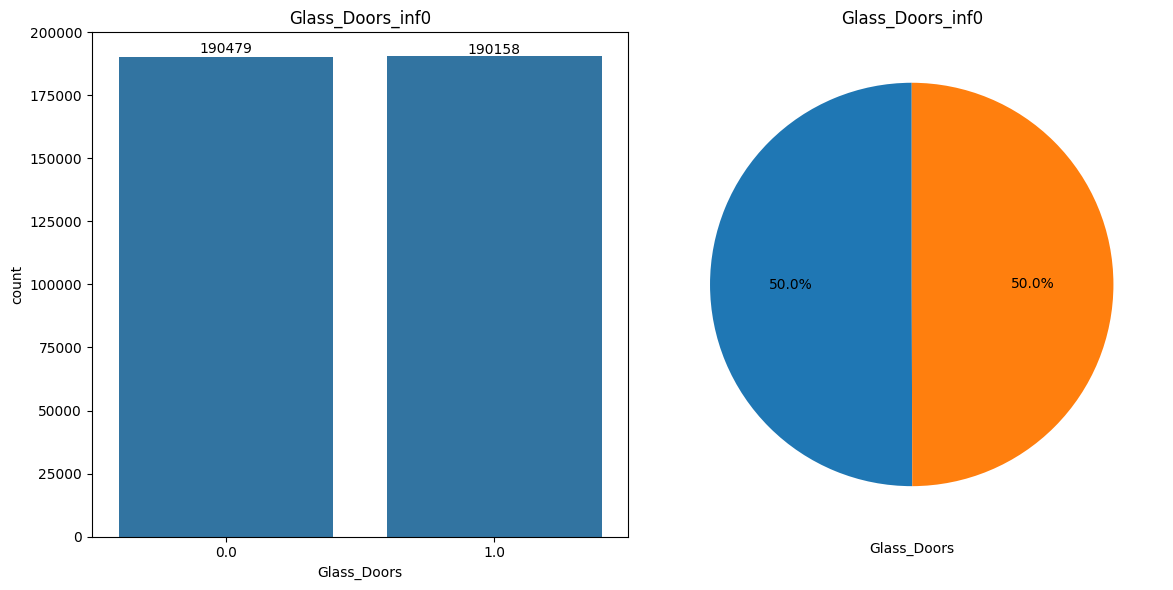

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Glass_Doors_inf0.index, y=Glass_Doors_inf0.values, ax=ax[0])
ax[0].set_title('Glass_Doors_inf0')
ax[0].set_xlabel('Glass_Doors')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Glass_Doors_inf0):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Glass_Doors_inf0, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Glass_Doors_inf0')
ax[1].set_xlabel('Glass_Doors')

plt.tight_layout()
plt.show()

In [ ]:
Swiming_Pool_inf0 = df['Swiming Pool'].value_counts()
Swiming_Pool_inf0

,count
Swiming Pool,
1.0,190657
0.0,189980


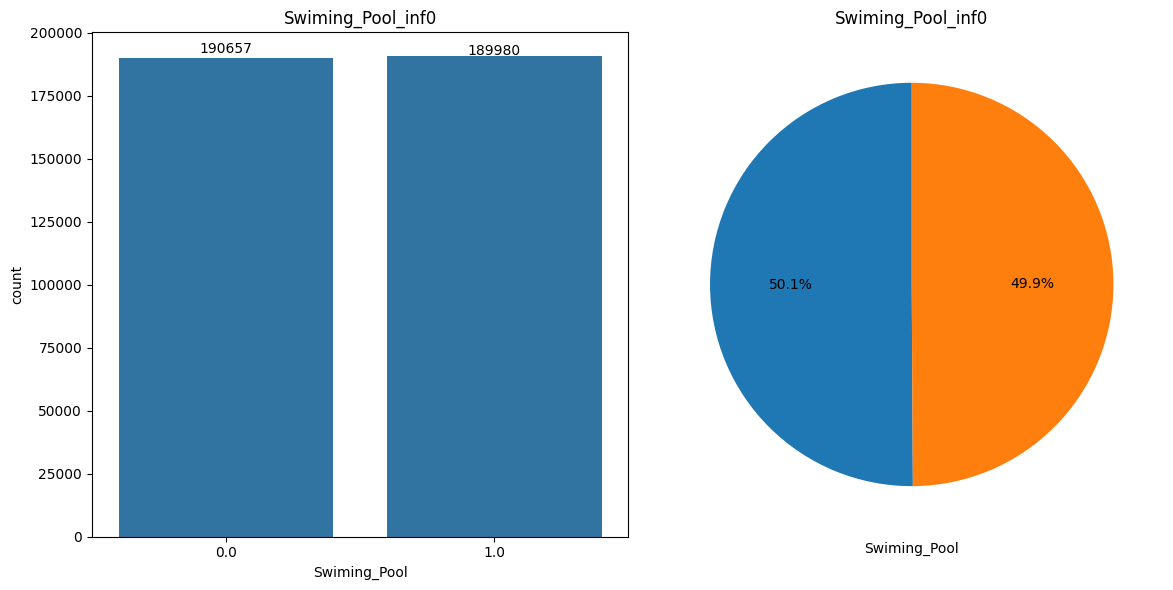

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Swiming_Pool_inf0.index, y=Swiming_Pool_inf0.values, ax=ax[0])
ax[0].set_title('Swiming_Pool_inf0')
ax[0].set_xlabel('Swiming_Pool')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Swiming_Pool_inf0):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Swiming_Pool_inf0, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Swiming_Pool_inf0')
ax[1].set_xlabel('Swiming_Pool')

plt.tight_layout()
plt.show()

In [ ]:
Garden_info = df['Garden'].value_counts()
Garden_info

,count
Garden,
1.0,190929
0.0,189708


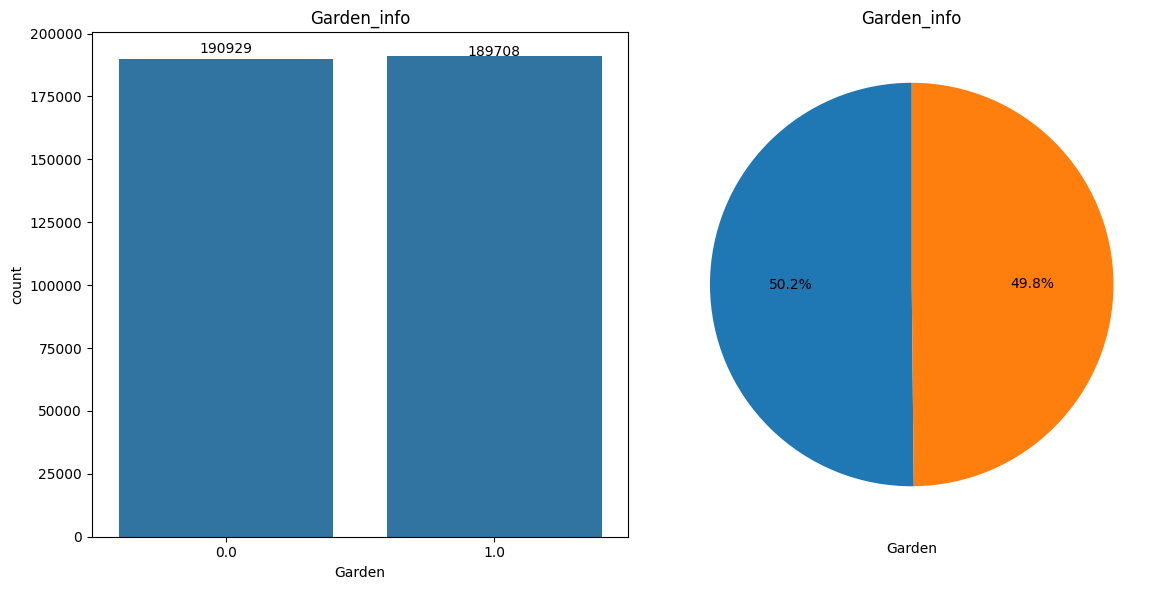

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
sns.barplot(x=Garden_info.index, y=Garden_info.values, ax=ax[0])
ax[0].set_title('Garden_info')
ax[0].set_xlabel('Garden')
ax[0].set_ylabel('count')
##################################################################################
for i, count in enumerate(Garden_info):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
####################################################################################
ax[1].pie(Garden_info, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Garden_info')
ax[1].set_xlabel('Garden')

plt.tight_layout()
plt.show()

In [ ]:
Prices_inf0 = df['Prices'].value_counts()
Prices_inf0

,count
Prices,
38525.0,355
39550.0,346
36725.0,338
38025.0,338
38425.0,335
...,...
9875.0,1
9425.0,1
76950.0,1


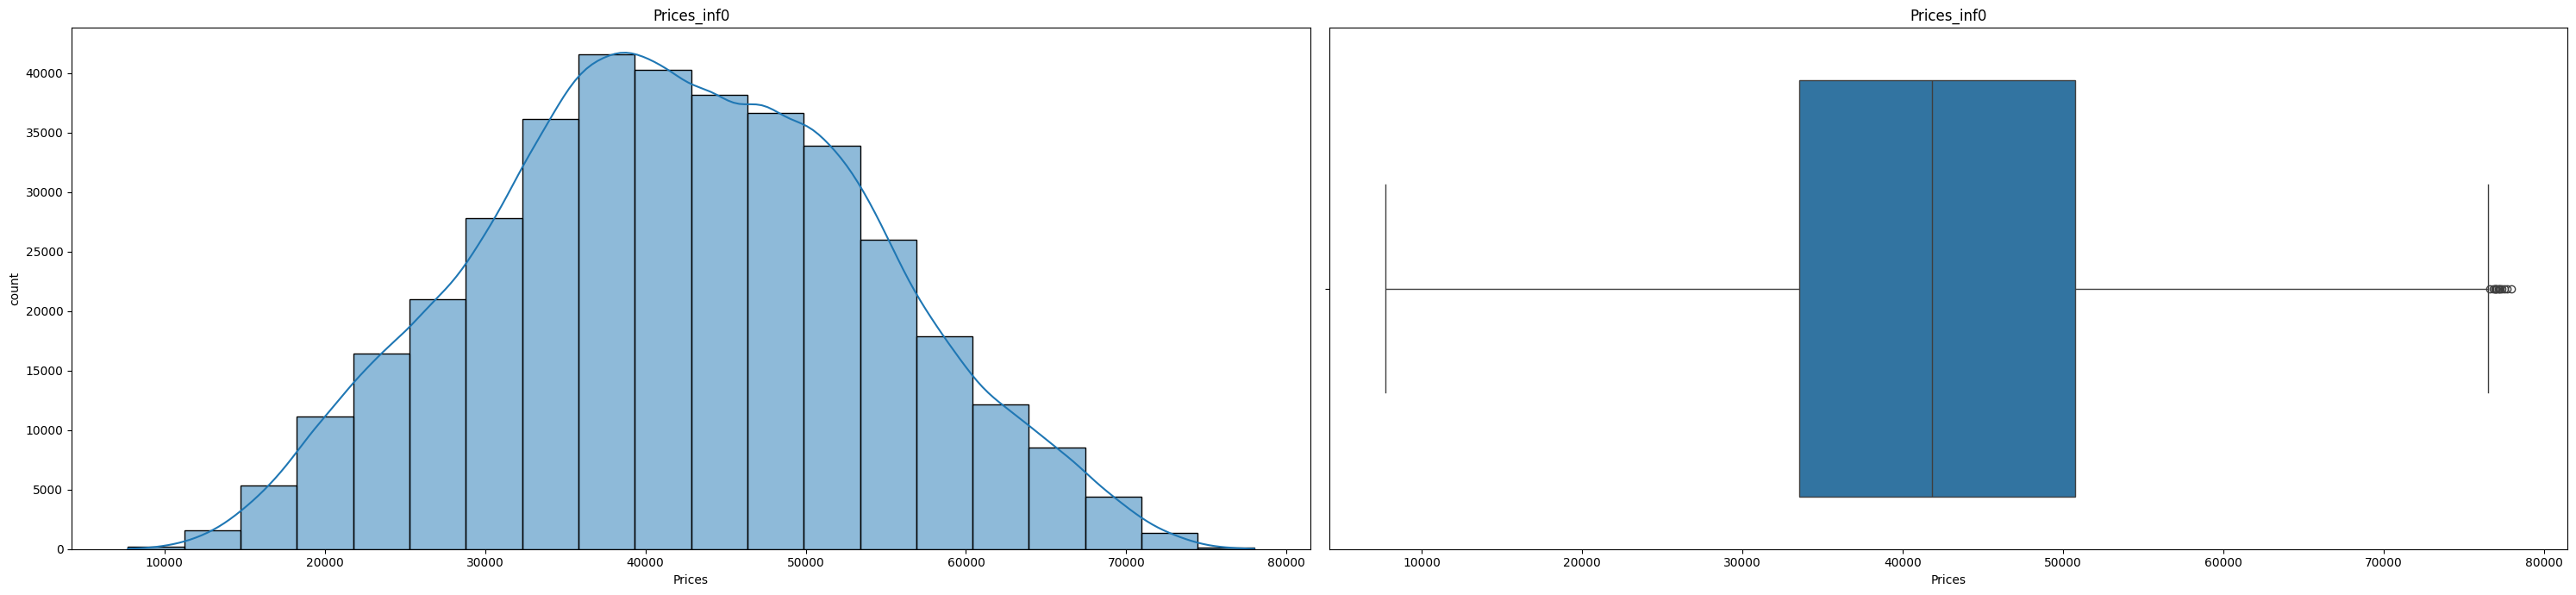

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(30, 7))
sns.histplot(df['Prices'], bins=20, kde=True,  ax=ax[0])
ax[0].set_title('Prices_inf0')
ax[0].set_xlabel('Prices')
ax[0].set_ylabel('count')
##################################################################################
sns.boxplot(x= df['Prices'], orient='h', ax= ax[1])
ax[1].set_title('Prices_inf0')
ax[1].set_xlabel('Prices')

plt.tight_layout()
plt.show()

In [ ]:
#check outliers for prices
len(df['Prices'])

380638

In [ ]:
q1 = df['Prices'].quantile(0.25)
q3 = df['Prices'].quantile(0.75)
iqr = q3 - q1

# lower bound & upper bound for outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#calculate the outliers
print('number of outliers:', len(df) - len(df[(df['Prices'] >= lower_bound) & (df['Prices'] <= upper_bound)]))

number of outliers: 14


/tmp/ipython-input-2276629661.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Area', palette='pastel', ax=axes[0, 0])
/tmp/ipython-input-2276629661.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Garage', palette='pastel', ax=axes[0, 1])
/tmp/ipython-input-2276629661.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FirePlace', palette='pastel', ax=axes[1, 0])
/tmp/ipython-input-2276629661.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

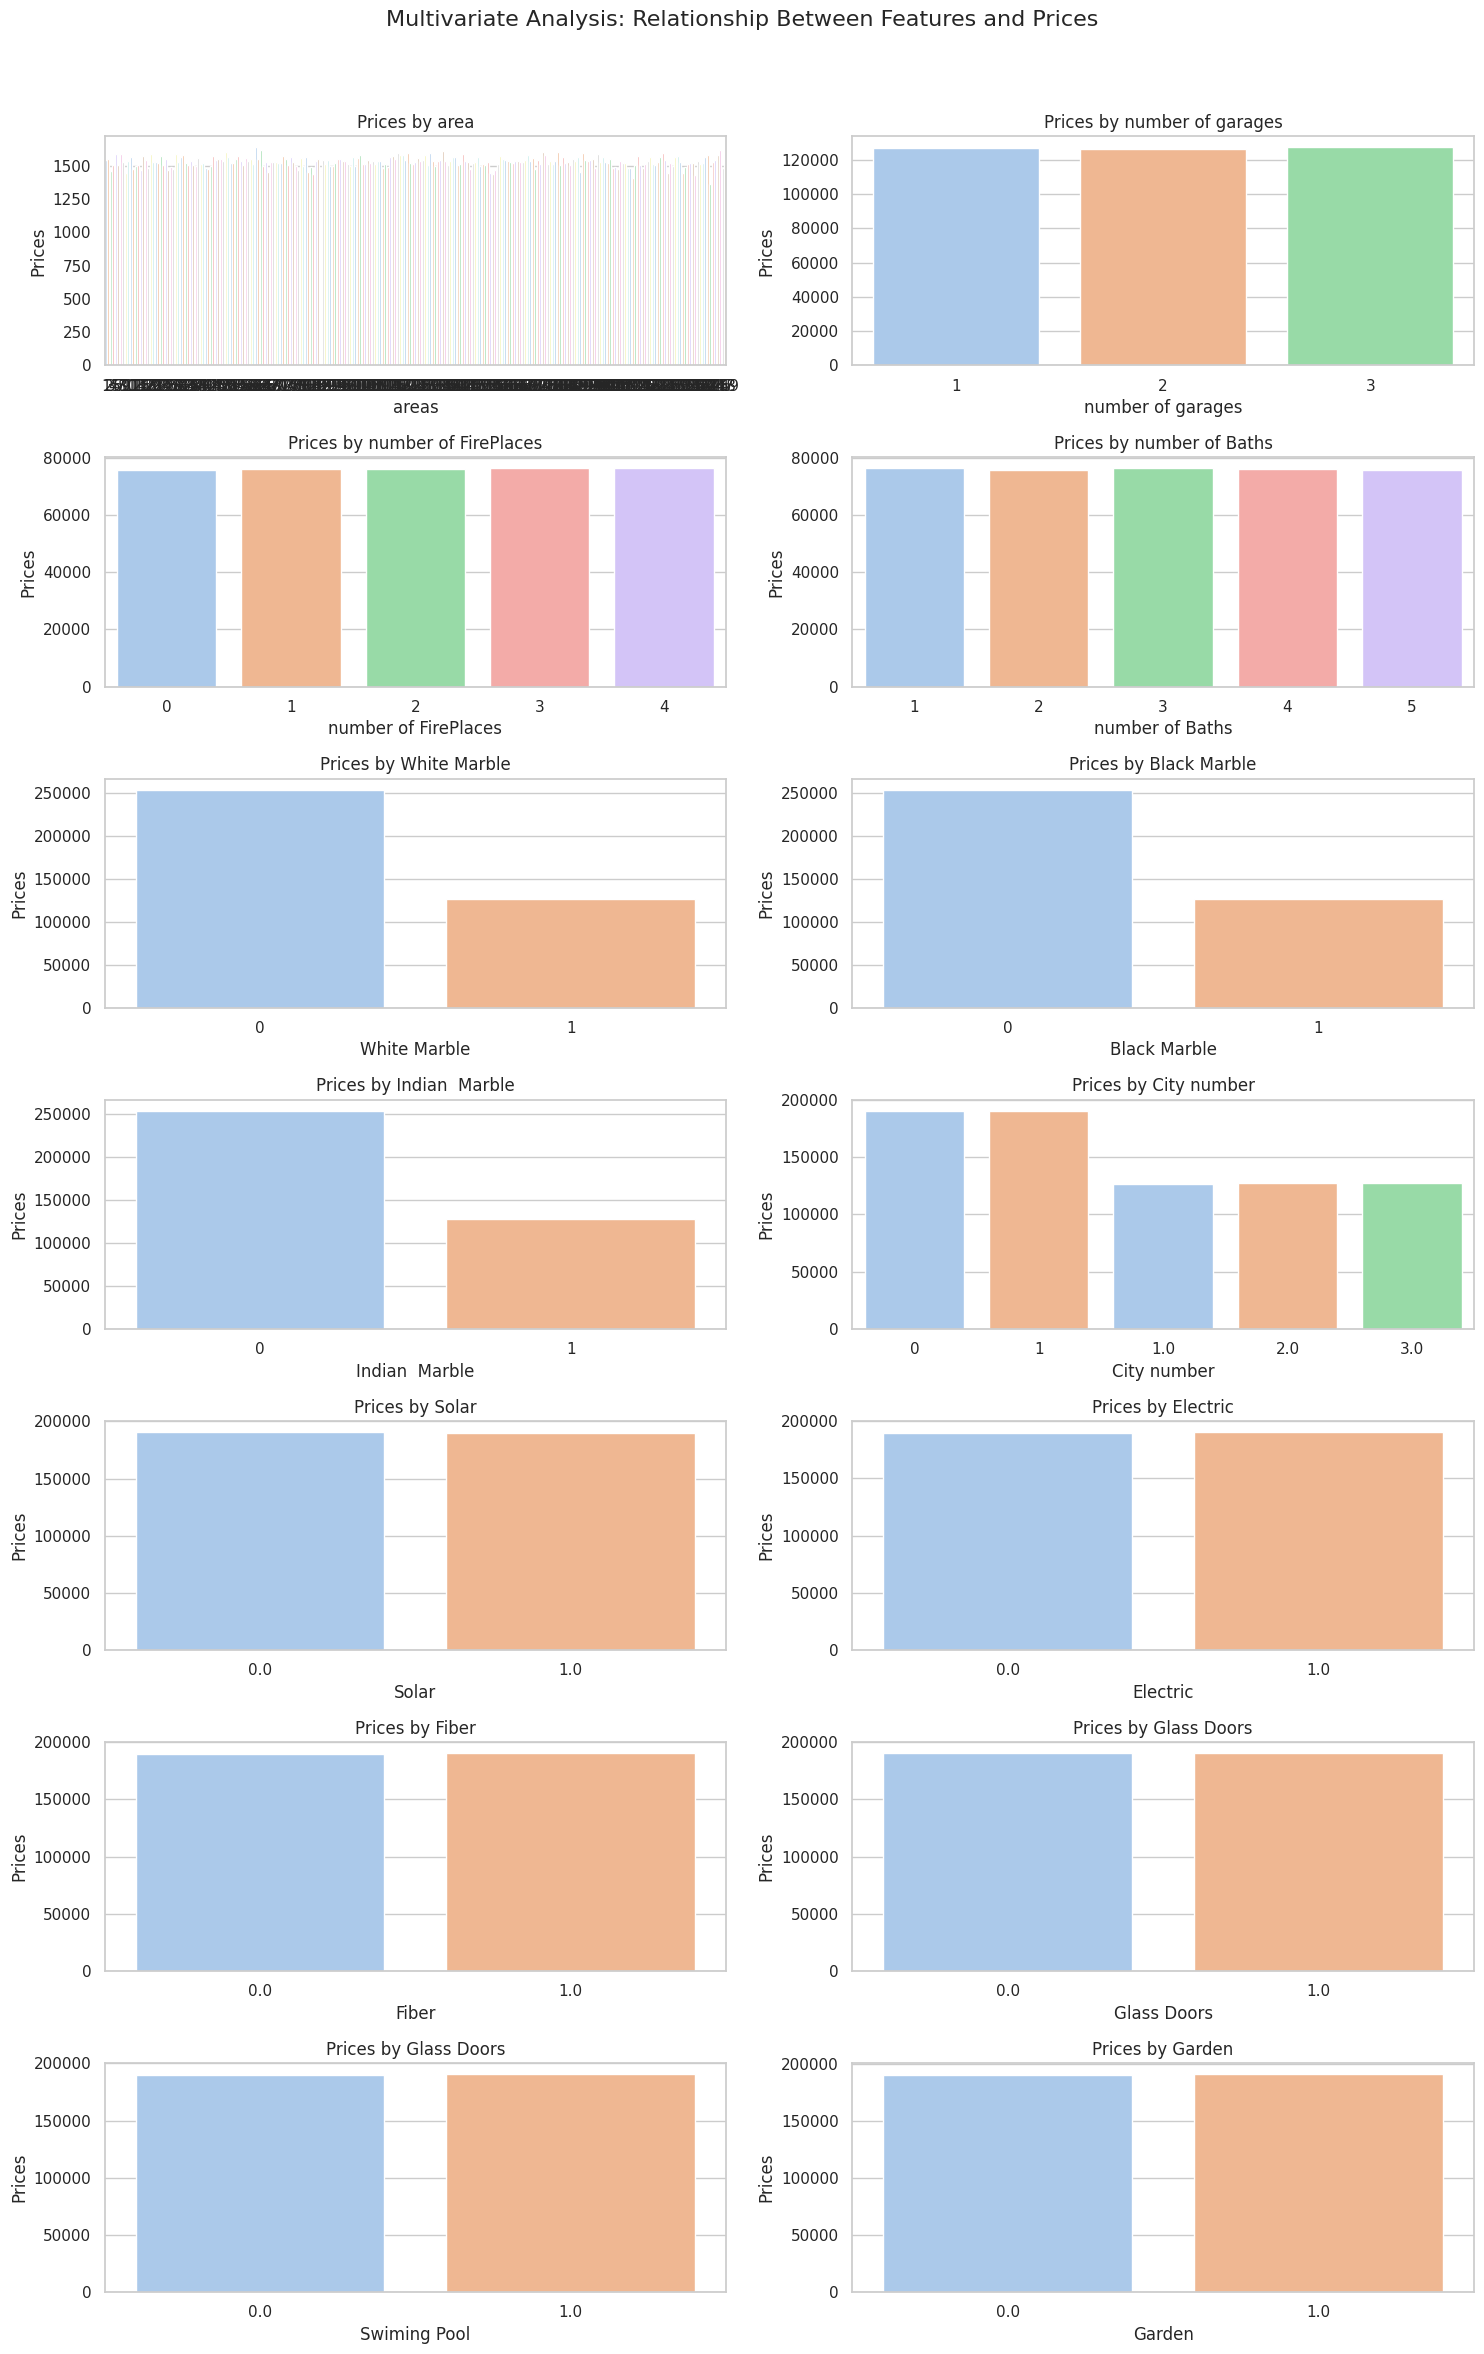

In [ ]:
# multivariate Analysis
sns.set(style='whitegrid')

fig, axes = plt.subplots(7, 2, figsize=(15, 24))
fig.suptitle('Multivariate Analysis: Relationship Between Features and Prices', fontsize=16)
#area vs Prices
sns.countplot(data=df, x='Area', palette='pastel', ax=axes[0, 0])
axes[0,0].set_title('Prices by area')
axes[0,0].set_xlabel('areas')
axes[0,0].set_ylabel('Prices')

# number of garages vs Prices
sns.countplot(data=df, x='Garage', palette='pastel', ax=axes[0, 1])
axes[0,1].set_title('Prices by number of garages')
axes[0,1].set_xlabel('number of garages')
axes[0,1].set_ylabel('Prices')

# number of FirePlaces vs Prices
sns.countplot(data=df, x='FirePlace', palette='pastel', ax=axes[1, 0])
axes[1,0].set_title('Prices by number of FirePlaces')
axes[1,0].set_xlabel('number of FirePlaces')
axes[1,0].set_ylabel('Prices')

# number of Baths vs Prices
sns.countplot(data=df, x='Baths', palette='pastel', ax=axes[1, 1])
axes[1,1].set_title('Prices by number of Baths')
axes[1,1].set_xlabel('number of Baths')
axes[1,1].set_ylabel('Prices')

# White Marble vs Prices
sns.countplot(data=df, x='White Marble', palette='pastel', ax=axes[2, 0])
axes[2,0].set_title('Prices by White Marble')
axes[2,0].set_xlabel('White Marble')
axes[2,0].set_ylabel('Prices')

# Black Marble vs Prices
sns.countplot(data=df, x='Black Marble', palette='pastel', ax=axes[2, 1])
axes[2,1].set_title('Prices by Black Marble')
axes[2,1].set_xlabel('Black Marble')
axes[2,1].set_ylabel('Prices')

# Indian Marble vs Prices
sns.countplot(data=df, x='Indian Marble', palette='pastel', ax=axes[3, 0])
axes[3,0].set_title('Prices by Indian  Marble')
axes[3,0].set_xlabel('Indian  Marble')
axes[3,0].set_ylabel('Prices')

# Floors vs Prices
sns.countplot(data=df, x='Floors', palette='pastel', ax=axes[3, 1])
axes[3,1].set_title('Prices by Floors')
axes[3,1].set_xlabel('Floors')
axes[3,1].set_ylabel('Prices')

# City number vs Prices
sns.countplot(data=df, x='City', palette='pastel', ax=axes[3, 1])
axes[3,1].set_title('Prices by City number')
axes[3,1].set_xlabel('City number')
axes[3,1].set_ylabel('Prices')

# Solar vs Prices
sns.countplot(data=df, x='Solar', palette='pastel', ax=axes[4, 0])
axes[4,0].set_title('Prices by Solar')
axes[4,0].set_xlabel('Solar')
axes[4,0].set_ylabel('Prices')

# Electric vs Prices
sns.countplot(data=df, x='Electric', palette='pastel', ax=axes[4, 1])
axes[4,1].set_title('Prices by Electric')
axes[4,1].set_xlabel('Electric')
axes[4,1].set_ylabel('Prices')

# Fiber vs Prices
sns.countplot(data=df, x='Fiber', palette='pastel', ax=axes[5, 0])
axes[5,0].set_title('Prices by Fiber')
axes[5,0].set_xlabel('Fiber')
axes[5,0].set_ylabel('Prices')

# Glass Doors vs Prices
sns.countplot(data=df, x='Glass Doors', palette='pastel', ax=axes[5, 1])
axes[5,1].set_title('Prices by Glass Doors')
axes[5,1].set_xlabel('Glass Doors')
axes[5,1].set_ylabel('Prices')

# Swiming Pool vs Prices
sns.countplot(data=df, x='Swiming Pool', palette='pastel', ax=axes[6, 0])
axes[6,0].set_title('Prices by Glass Doors')
axes[6,0].set_xlabel('Swiming Pool')
axes[6,0].set_ylabel('Prices')

# Garden vs Prices
sns.countplot(data=df, x='Garden', palette='pastel', ax=axes[6, 1])
axes[6,1].set_title('Prices by Garden')
axes[6,1].set_xlabel('Garden')
axes[6,1].set_ylabel('Prices')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
plt.show()

/tmp/ipython-input-2748163260.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_categories, y=prices_count, palette='pastel', ax=ax1)


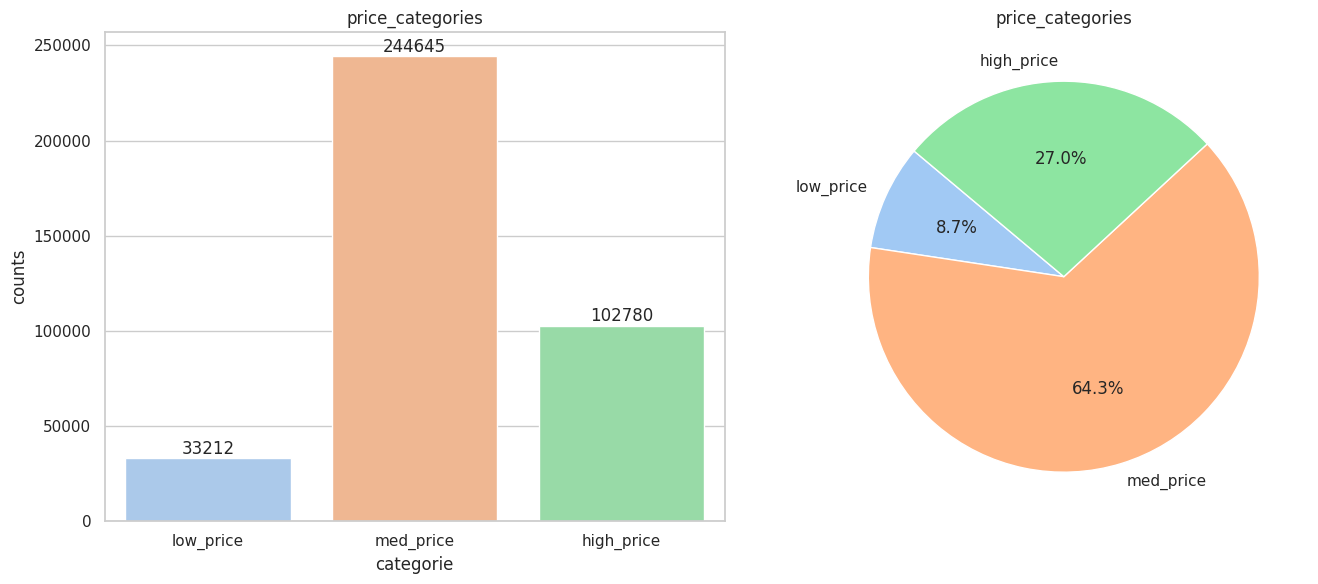

In [ ]:
low_price =  df[df['Prices'] < 25000]
med_price = df[(df['Prices'] >= 25000) & (df['Prices'] <= 50000) ]
high_price =df[df['Prices'] > 50000]

price_categories = ['low_price', 'med_price', 'high_price']
prices_count = [len(low_price), len(med_price), len(high_price)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=price_categories, y=prices_count, palette='pastel', ax=ax1)
ax1.set_title('price_categories')
ax1.set_xlabel('categorie')
ax1.set_ylabel('counts')

for i,count in enumerate(prices_count):
  ax1.text(i, count + 50, str(count), ha='center', va='bottom')

ax2.pie(prices_count, labels=price_categories, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
ax2.set_title('price_categories')

plt.tight_layout()
plt.show()

In [ ]:
df.isna().sum()

,0
Area,0
Garage,0
FirePlace,0
Baths,0
White Marble,0
Black Marble,0
Indian Marble,0
Floors,0
City,1
Solar,1


In [ ]:
print('number of duplicated rows:',  df.duplicated().sum())

number of duplicated rows: 3306


In [ ]:
df = df.drop_duplicates()

print('number of duplicated rows after drop:',  df.duplicated().sum())

number of duplicated rows after drop: 0


In [ ]:
# print("Number of remaining rows: ", df.shape[0])

In [ ]:
df = pd.get_dummies(data=df)
df.head()

,Area,Garage,FirePlace,Baths,White Marble,Black Marble,Indian Marble,Floors,City,Solar,Electric,Fiber,Glass Doors,Swiming Pool,Garden,Prices
0,164,2,0,2,0,1,0,0,3.0,1.0,1.0,1.0,1.0,0.0,0.0,43800.0
1,84,2,0,4,0,0,1,1,2.0,0.0,0.0,0.0,1.0,1.0,1.0,37550.0
2,190,2,4,4,1,0,0,0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,49500.0
3,75,2,4,4,0,0,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,50075.0
4,148,1,4,2,1,0,0,1,2.0,1.0,0.0,0.0,1.0,1.0,1.0,52400.0


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
colmuns_to_scale = ['Area', 'Garage', 'FirePlace', 'Baths', 'City', 'Prices']
scaler.fit(df[colmuns_to_scale])
scaled_colmuns = scaler.transform(df[colmuns_to_scale])
df[colmuns_to_scale] = scaled_colmuns

In [ ]:
df

,Area,Garage,FirePlace,Baths,White Marble,Black Marble,Indian Marble,Floors,City,Solar,Electric,Fiber,Glass Doors,Swiming Pool,Garden,Prices
0,0.657258,0.5,0.00,0.25,0,1,0,0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.513523
1,0.334677,0.5,0.00,0.75,0,0,1,1,0.5,0.0,0.0,0.0,1.0,1.0,1.0,0.424555
2,0.762097,0.5,1.00,0.75,1,0,0,0,0.5,0.0,0.0,1.0,0.0,0.0,0.0,0.594662
3,0.298387,0.5,1.00,0.75,0,0,1,1,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.602847
4,0.592742,0.0,1.00,0.25,1,0,0,1,0.5,1.0,0.0,0.0,1.0,1.0,1.0,0.635943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380633,0.116935,1.0,1.00,0.00,0,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.092883
380634,0.596774,0.5,0.25,0.00,0,1,0,0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.383630
380635,0.491935,0.0,0.25,0.00,0,1,0,0,0.5,0.0,0.0,0.0,0.0,1.0,0.0,0.168683
380636,0.737903,1.0,0.50,0.50,1,0,0,0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.628114


In [ ]:
# Fill missing values with the mean
df = df.fillna(df.mean())

X = df.drop('Prices', axis=1)
y = df['Prices']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("shape of X train: ", X_train.shape)
print("shape of X test: ", X_test.shape)

shape of X train:  (301865, 15)
shape of X test:  (75467, 15)


In [ ]:
#@title Training models

dict_models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(), # Added as an alternative to Linear Regression
    'K-NN Regressor': KNeighborsRegressor(n_neighbors=3),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=10),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=60, random_state=0),
    'SVR': SVR(kernel="linear"),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=10),
    'XGBoost Regressor': xgb.XGBRegressor(random_state=10),
    'LightGBM Regressor': lgb.LGBMRegressor(random_state=10)
}

list_models_mse = []
list_models_r2 = []
list_models_name = []

for name, model in dict_models.items():
    list_models_name.append(name)
    model.fit(X_train, y_train)
    predict = model.predict(X_test)

    mse = mean_squared_error(y_test, predict)
    r2 = r2_score(y_test, predict)

    list_models_mse.append(mse)
    list_models_r2.append(r2)

    print(name, ": Test MSE = ", mse)
    print(name, ": Test R2 Score = ", r2)
    print("-" * 30)

Linear Regression : Test MSE =  1.6588870623160605e-07
Linear Regression : Test R2 Score =  0.9999944294068219
------------------------------
Lasso : Test MSE =  0.029779425442369018
Lasso : Test R2 Score =  -2.1579750666411712e-06
------------------------------
K-NN Regressor : Test MSE =  9.624110907273042e-05
K-NN Regressor : Test R2 Score =  0.9967681943043227
------------------------------
Decision Tree Regressor : Test MSE =  3.555865247640596e-05
Decision Tree Regressor : Test R2 Score =  0.9988059296415941
------------------------------
Random Forest Regressor : Test MSE =  1.4953602636192726e-05
Random Forest Regressor : Test R2 Score =  0.9994978534782468
------------------------------
SVR : Test MSE =  0.004507239163244293
SVR : Test R2 Score =  0.8486455388980982
------------------------------
Gradient Boosting Regressor : Test MSE =  8.69546977005456e-05
Gradient Boosting Regressor : Test R2 Score =  0.9970800348208566
------------------------------
XGBoost Regressor : Tes

In [ ]:
df_models_results = pd.DataFrame({'model_name': list_models_name, 'MSE': list_models_mse, "R2":list_models_r2})
display(df_models_results)

,model_name,MSE,R2
0,Linear Regression,1.658887e-07,0.999994
1,Lasso,2.977943e-02,-0.000002
2,K-NN Regressor,9.624111e-05,0.996768
3,Decision Tree Regressor,3.555865e-05,0.998806
4,Random Forest Regressor,1.495360e-05,0.999498
5,SVR,4.507239e-03,0.848646
6,Gradient Boosting Regressor,8.695470e-05,0.997080
7,XGBoost Regressor,2.195690e-05,0.999263
8,LightGBM Regressor,1.369037e-05,0.999540


In [ ]:
# Fill missing values with the mean
df = df.fillna(df.mean())

X = df.drop('Prices', axis=1)
y = df['Prices']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- Model 1: Linear Regression ---
print("--- Linear Regression Model ---")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}\n")


# --- Model 2: Random Forest Regressor ---
print("--- Random Forest Regressor Model ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

--- Linear Regression Model ---
Mean Squared Error (MSE): 0.00
R-squared (R2): 1.00

--- Random Forest Regressor Model ---
Mean Squared Error (MSE): 0.00
R-squared (R2): 1.00


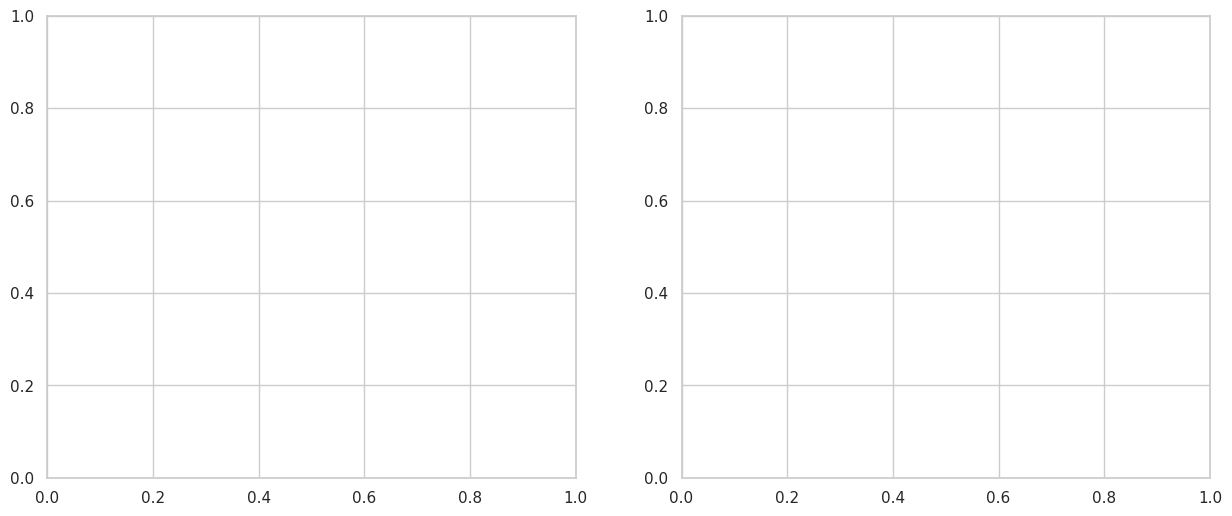

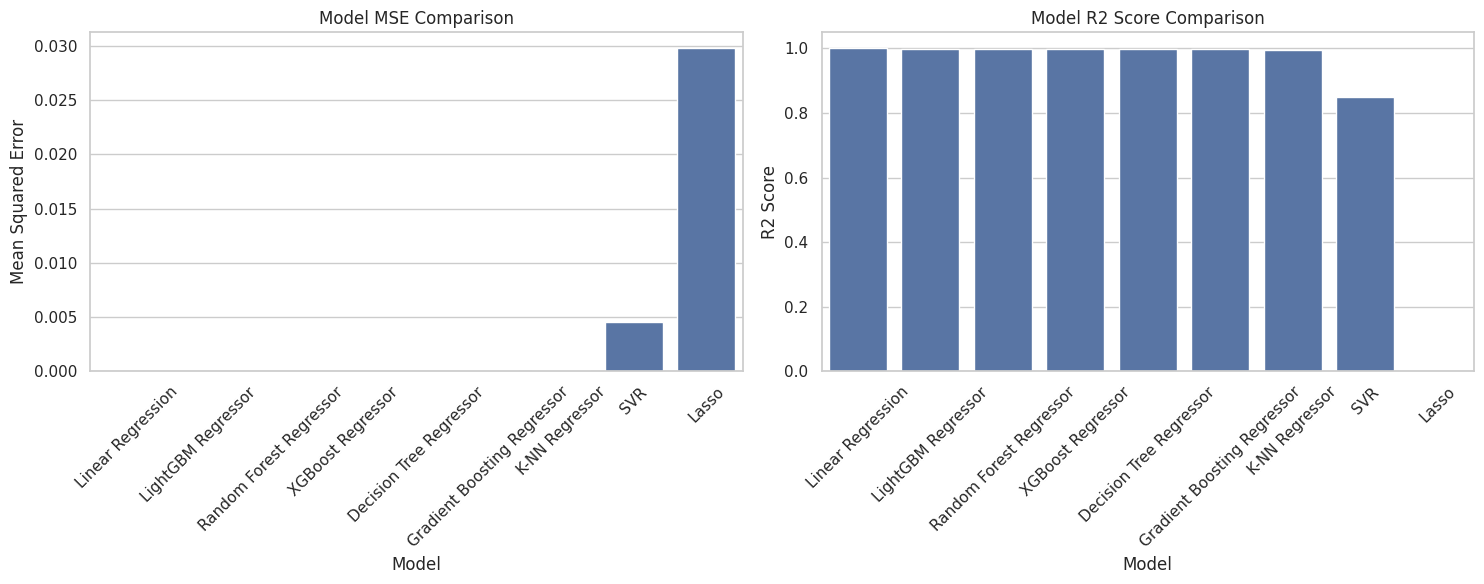

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


# Sort the dataframes for plotting
df_mse_sorted = df_models_results.sort_values(by='MSE', ascending=True)
df_r2_sorted = df_models_results.sort_values(by='R2', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot MSE
sns.barplot(x='model_name', y='MSE', data=df_mse_sorted, ax=axes[0])
axes[0].set_title('Model MSE Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Mean Squared Error')
axes[0].tick_params(axis='x', rotation=45)

# Plot R2 Score
sns.barplot(x='model_name', y='R2', data=df_r2_sorted, ax=axes[1])
axes[1].set_title('Model R2 Score Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison_charts.png')